In [16]:
from imagegrains import data_loader, segmentation_helper, plotting
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Download pre-trained models and demo data  

In [17]:
import os
from pathlib import Path

home_path = os.getcwd()
home_path = Path(home_path).parents[0]
# home_path = str(home_path)
home_path

WindowsPath('f:/git/grain_seg_ml')

Instead of using the demo files, you can use your own files. To do so, please change the paths in the following cell to your own files (and skip the next two cells).

In [18]:
# set the path to the folder that contains the images for segmentation
image_path = "F:/cellpose/fh/"

# set the path to the trained model
model_path = "F:/cellpose/fh/models/fh_boosted_1.170223"


If you have not donwloaded the pre-trained models and demo data yet from github, please run the following cell to download them.

In [19]:
download_path = data_loader.download_files()
print("Files saved to: ", download_path)

Files saved to:  C:/Users/Mair/imagegrains


To use the demo files, please run the following cell.

In [20]:
image_path = f'{download_path}/demo_data/FH/'
model_path = f'{download_path}/models/fh_boosted_1.170223'

## Predict masks for dataset  
Predictions are made with every model in `model_dir` for any image of a specific format (default= jpg) in the `image_path` directory.   
- `image_path` can contain sub-directories named 'train', 'test'; alternatively setting `do_subfolders=True` allows to use any existing subfolder.  
- Allowed image formats are: `jpg`, `png`, `tif`.
- Images with 'flow', 'flows','masks'or 'mask' in the file name will be ignored.
- Mask will be stored by default as tif files. 

In [21]:
#run the segmentation
segmentation_helper.predict_dataset(image_path,model_path,mute=True,return_results=False,save_masks=True, model_id='fh_boosted_1');

C:/Users/Mair/imagegrains/demo_data/FH/train: 100%|██████████| 6/6 [02:12<00:00, 22.12s/image]


## Predict masks for images in a specific folder   
This function takes in a directory containing images, and uses a pre-trained model to predict segmentation masks for the images.
If `return_results` is `True` respective lists of 1D arrays for predicted *masks*, *flows* and *styles* 
from `CellposeModel.eval()` are returned (see https://cellpose.readthedocs.io/en/latest/api.html#id5).

Parameters:
------------
`image_path (str)` - Input directory 
model (obj) - Trained model from 'models.CellposeModel' class. Use either `models.CellposeModel(model_type='')` for built-in cellpose models or `models.CellposeModel(pretrained_model='')` for custom models. See https://cellpose.readthedocs.io/en/latest/models.html for more details.   
   
`image_format` (str(optional, default 'jpg')) - Image format of the images in `image_path`   
`filter_str` (str(optional, default '')) - A string used to filter the images in `image_path`   
`return_results` (bool(optional, default False)) - flag for returning predicted masks, flows and styles  
  
`tar_dir` (str(optional, default '')) - The directory to save the predicted masks to.  
`save_masks` (bool(optional, default True)) - flag for saving predicted mask as `.tif` files in `tar_dir`   
`mute` (bool (optional, default=False)) - flag for muting console output   
`model_id` (str (optional, default = '')) - optional model name that will be written into output file names - will be later used to filter the results for a specific model.  

Parameters that can be handed down explicitly to `CellposeModel.eval()`,    
see https://cellpose.readthedocs.io/en/latest/api.html#id5 :   
   
`channels` (list (optional, default [0,0]))   
`diameter` (float (optional, default None))   
`min_size` (int (optional, default 15))    

In [22]:
#import the cellpose module for the model
from cellpose import models
#absolute path to images
image_path1 = f'{image_path}/test'
image_path2 = f'{image_path}/train'
#absolute path to custom model
model_path2 = f'{download_path}/models/full_set_1.170223'
#initialiize the models
model = models.CellposeModel(gpu=True, pretrained_model=model_path2)
#segement the images in PATH1 and PATH2
for path in [image_path1,image_path2]:
    segmentation_helper.predict_folder(
        path,image_format='jpg',diameter=None,
        return_results=False,model=model,save_masks=True,mute =True,model_id='custom_model');

C:/Users/Mair/imagegrains/demo_data/FH/train: 100%|██████████| 6/6 [00:22<00:00,  3.80s/image]


## Inspect segmentations   
`imgs` - list of image paths    
`preds` -  list of prediction paths   
`lbls` - list of label paths (optional)  
`title` - title of plot (optional)   
`tar_dir` - path to save plot (optional)   

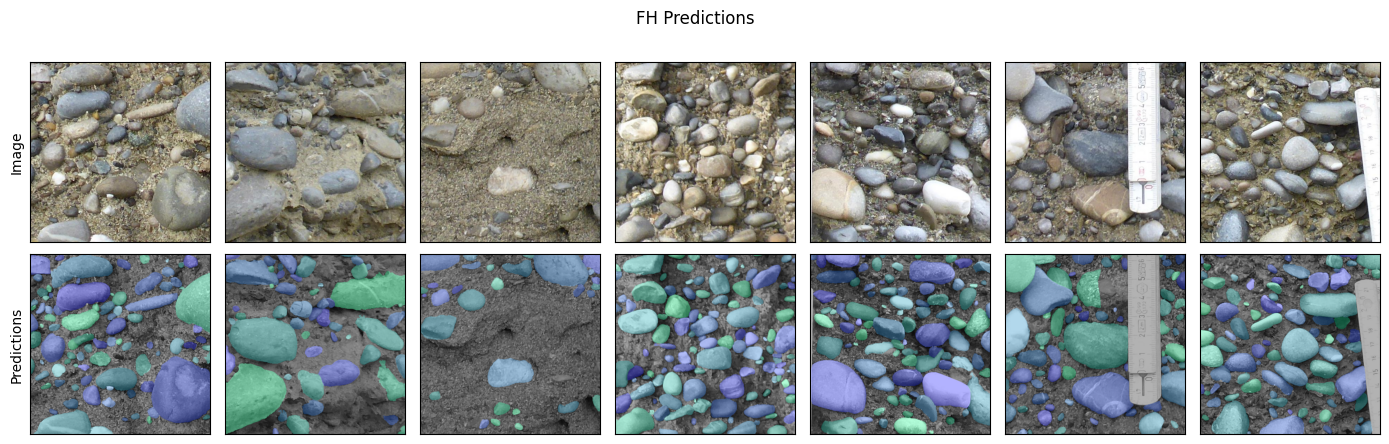

In [23]:
#load the images and predictions from PATH2
imgs,_,preds = data_loader.dataset_loader(image_path,label_str='mask',pred_str='_custom_model')
#show the results
pred_plot = plotting.inspect_predictions(imgs,preds,title='FH Predictions')

### Inspect segmentations, labels in images

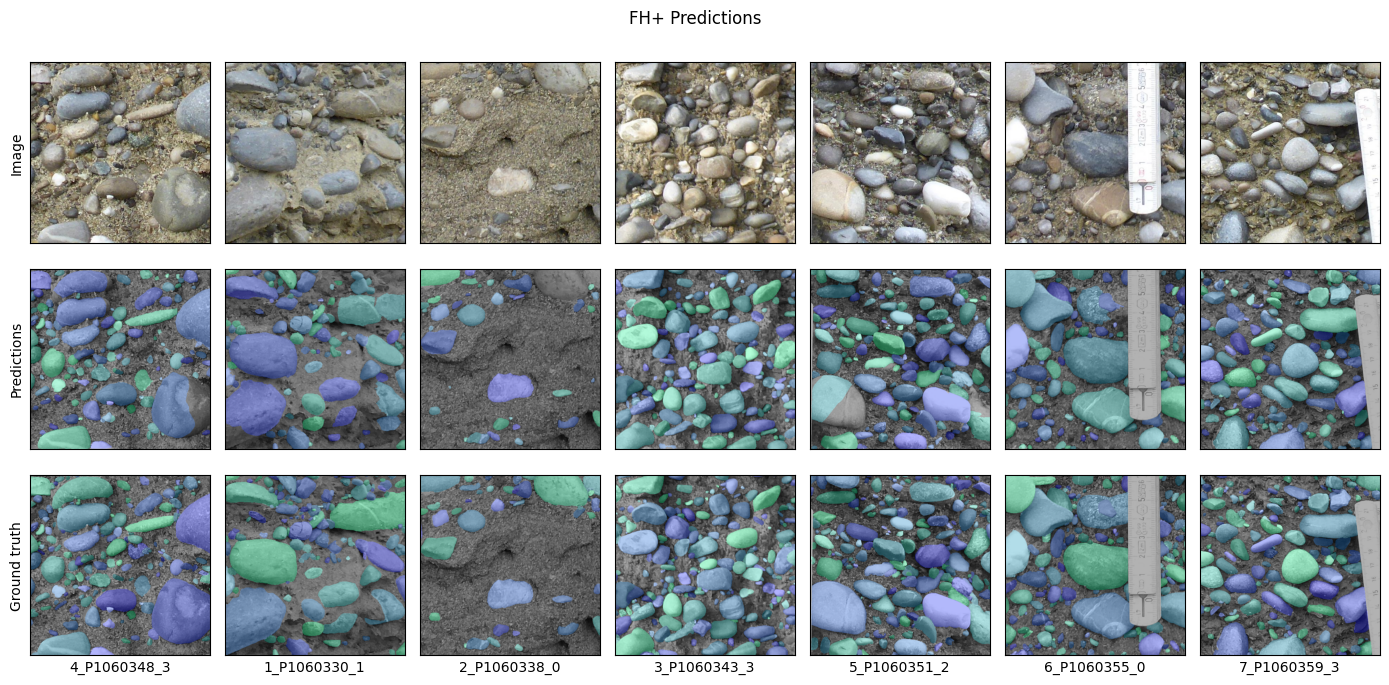

In [24]:
#load the images and the predictions from file
imgs,lbls,preds = data_loader.dataset_loader(image_path,label_str='mask',pred_str='fh_boosted_1_pred')
#additonally load the predictions from the second model 
_,_,preds2 = data_loader.dataset_loader(image_path,label_str='mask',pred_str='custom_model_pred')
#show the results
pred_label_plot = plotting.inspect_predictions(imgs,preds,lbls,title='FH+ Predictions')

## Evaluate segmentation performance  
If ground truth labels are available, the segmentation performance can be evaluated using the `eval_set()` function for a dataset with `test` and `train` folders or a single folder. For individual images, the `eval_image()` function can be used. Both functions save results to a `.pkl` file if enabled. If a test/train split in corresponding folders exist, by default results will be returned for the test at the beginning of the result dict.

Parameters:
------------
`imgs` (list) - List of images  
`lbls` (list) - List of labels  
`preds` (list) - List of predictions  
`data_id` (str (optional, default='')) - ID for the dataset  
`tar_dir` (str (optional, default='')) - Directory to save results to  
`thresholds` (list (optional, default=[0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1])) - Thresholds to evaluate at  
   
`filters` (dict (optional, default={'edge':[False,.05],'px_cutoff':[False,10]})) - Dictionary of filters to apply to labels and predictions. The `edge` filter, suppresses grains within the fraction of the image size specified by the second value. The `px_cutoff` filter suppresses grains smaller than the specified number of pixels (specifically, the minor axis length of grain is used).
     
`filter_props` (list (optional, default=['label','area','centroid','major_axis_length','minor_axis_length'])) - Poperties to filter on.  
     
`save_results` (bool (optional, default=True)) - Flag whether to save results to a pkl file  
`return_results` (bool (optional, default=True)) - Flag whether to return results  

Returns
------------
`eval_results` (dict) - Dictionary of evaluation results if enabled

In [25]:
#set the filters for the evaluation 
filters={'edge':[False,.05],'px_cutoff':[True,12]}
#eval mAP for IoU values (by default 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95. 1.0)
eval_results_fh_boosted= segmentation_helper.eval_set(imgs,lbls,preds,data_id='FH_boosted',filters=filters)
eval_results_full_set = segmentation_helper.eval_set(imgs,lbls,preds2,data_id='Custom_full_set',filters=filters)

### Plot segmentation performance  
The segmentation performance for a given dataset can be plotted a average precision over IoU thrshold curves. The results can be loaded from a `.pkl` file or directly passed from `eval_set()`. If a test/train split is used, the test indeces can be passed to differentiate the test from the train results in the `AP_IoU_plot()`. For the `AP_IoU_summary()` plot, only test results are plotted if test indeces are provided.

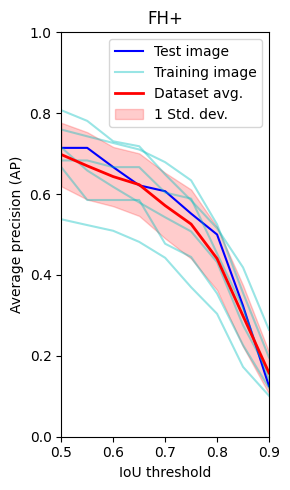

In [26]:
plt.figure(figsize=(3,5))
test_idxs1 = segmentation_helper.find_test_idxs(preds)
plotting.AP_IoU_plot(eval_results_fh_boosted,title='FH+',test_idxs=test_idxs1)

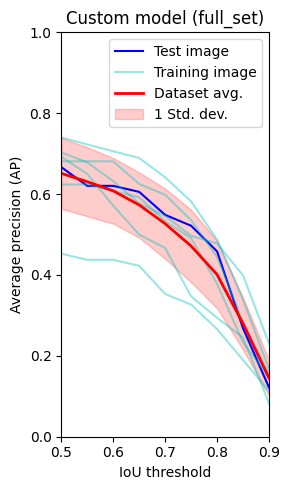

In [27]:
plt.figure(figsize=(3,5))
test_idxs2 = segmentation_helper.find_test_idxs(preds2)
plotting.AP_IoU_plot(eval_results_full_set,title='Custom model (full_set)',test_idxs=test_idxs2)

`elements` - dict with the elements to be plotted: 
>dataset = str with the name of the dataset  
>model_id = list with the identifier string for predictions from different models          
>colors = list of colors for the different models   
>images = bool, if True, plots the AP for each image   
>std = bool, if True, plots the standard deviation of the AP for each image  
>avg_model = bool, if True, plots the average AP for the dataset   

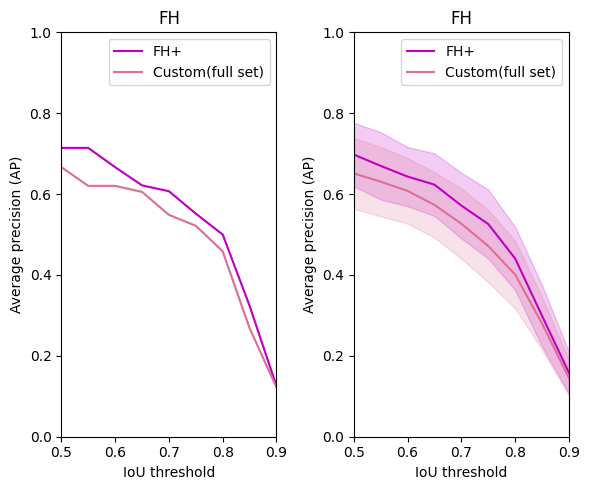

In [28]:
#configure the plot
elem = {
    'dataset':'FH',
    'model_id':['FH+','Custom(full set)'],
    'colors':['m','palevioletred'],
    'images':False,
    'std':True,
    'avg_model':True
    }

#concatenate the test indices
idx_list = test_idxs1+test_idxs2

#plot the results
plt.figure(figsize=(6,5))
plt.subplot(1,2,1)
plt.title('FH - test set')
plotting.AP_IoU_summary_plot([eval_results_fh_boosted,eval_results_full_set],elem,test_idx_list=idx_list)
plt.subplot(1,2,2)
plt.title('FH - all')
plotting.AP_IoU_summary_plot([eval_results_fh_boosted,eval_results_full_set],elem)

### Plot segmentation performance with images

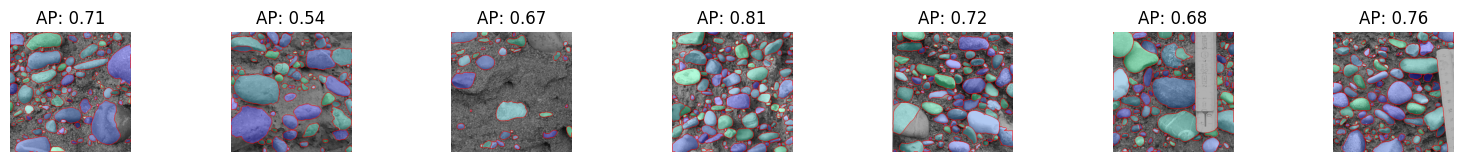

In [29]:
plotting.show_masks_set(preds,imgs,res_dict=eval_results_fh_boosted,show_ap50=True)